## **Import Libraries**

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

 ## **Load Data**

In [42]:
data_path = "../data_set/social_media_productivity_6000.csv"
df = pd.read_csv(data_path)

print(df.shape)

(6000, 9)


## **Data Analysis**

In [43]:
# Display all columns and rows
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


#### Exploratory Data Analysis

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age                    5880 non-null   float64
 1   daily_screen_time      5880 non-null   float64
 2   social_media_hours     5880 non-null   float64
 3   study_hours            5880 non-null   float64
 4   sleep_hours            5880 non-null   float64
 5   notifications_per_day  5880 non-null   float64
 6   focus_score            5880 non-null   float64
 7   addiction_level        5880 non-null   str    
 8   productivity_score     5880 non-null   float64
dtypes: float64(8), str(1)
memory usage: 422.0 KB


In [45]:
df.describe()

,age,daily_screen_time,social_media_hours,study_hours,sleep_hours,notifications_per_day,focus_score,productivity_score
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,27.111395,6.923175,4.145915,4.069328,6.514270,159.781463,96.363531,37.614051
std,7.268430,2.859055,2.155496,2.309472,1.434351,81.044666,7.416839,27.603251
min,15.000000,2.000000,0.660000,0.000000,4.000000,20.000000,47.390000,0.000000
25%,21.000000,4.470000,2.400000,2.120000,5.270000,89.000000,96.360000,13.565000
50%,27.000000,6.860000,3.755000,4.115000,6.525000,160.000000,100.000000,36.200000
75%,33.000000,9.360000,5.540000,6.030000,7.730000,231.000000,100.000000,58.560000
max,39.000000,11.990000,10.660000,8.000000,9.000000,299.000000,100.000000,100.000000


**Null Value Visualization**

<Axes: >

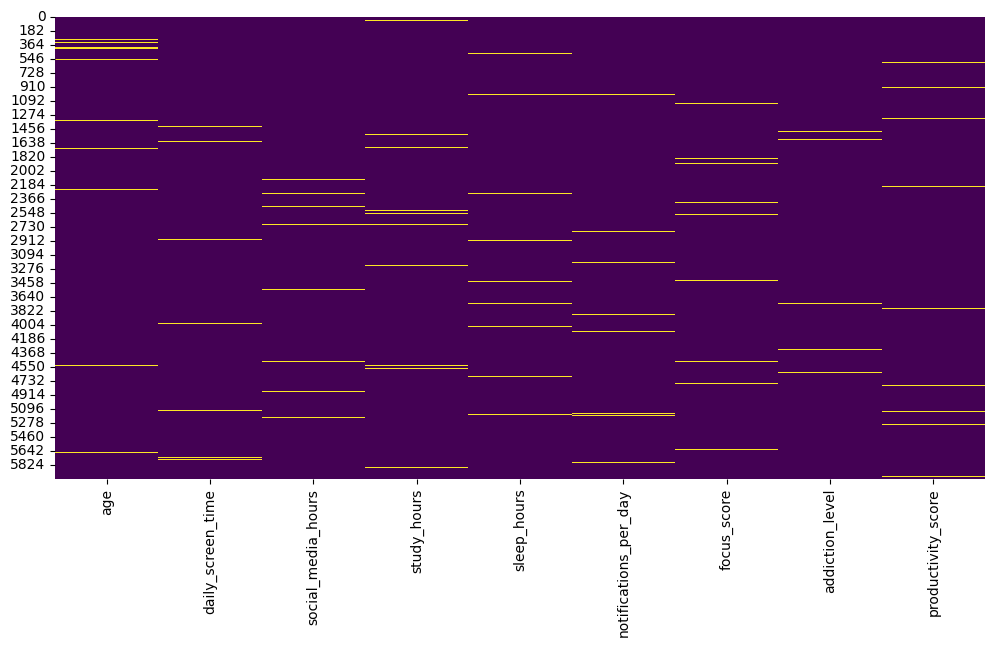

In [46]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')

In [47]:
null_count = df.isnull().sum() # Calculate the number of null values in each column and store it in a variable called 'null_count'
null_percent = (null_count / len(df)) * 100 # Calculate the percentage of null values in each column and store it in a variable called 'null_percent'
# print(null_count)
print(null_percent)

age                      2.0
daily_screen_time        2.0
social_media_hours       2.0
study_hours              2.0
sleep_hours              2.0
notifications_per_day    2.0
focus_score              2.0
addiction_level          2.0
productivity_score       2.0
dtype: float64


#### Data Cleaning

In [48]:
df.dropna(inplace=True)
print(df.isnull().sum())

age                      0
daily_screen_time        0
social_media_hours       0
study_hours              0
sleep_hours              0
notifications_per_day    0
focus_score              0
addiction_level          0
productivity_score       0
dtype: int64


### Feature Transformation


Categorical to Numerical

In [49]:
df_encoded = df.copy() # Create a copy of the original DataFrame to work with encoding
addiction_level_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}
df_encoded['addiction_level'] = df_encoded['addiction_level'].map(addiction_level_mapping) # Map the 'Addiction_Level' column to numerical values using the defined mapping

Splitting Data

In [50]:
df_clean = df_encoded.sample(frac=1, random_state=42).reset_index(drop=True)
split_index = int(len(df_clean) * 0.8) # Calculate the index for an 80-20 split of the training data
df_train = df_clean[:split_index] # Create the training set using the first 80
df_test = df_clean[split_index:] # Create the testing set using the remaining 20%

X_train = df_clean.drop('productivity_score', axis=1) # Define the features for training by dropping the target variable
y_train = df_clean['productivity_score'] # Define the target variable for training

X_test = df_test.drop('productivity_score', axis=1) # Define the features for testing by dropping the target variable
y_test = df_test['productivity_score'] # Define the target variable for testing

print(X_train.shape, y_train.shape) # Print the shapes of the training features and target variable


(4999, 8) (4999,)


## **Linear Regression Model**

#### **Linear Regression Model from scratch**

In [ ]:
def LinearRegressionScratch(X_train, y_train, X_test, y_test):
    # Convert the training and testing data to NumPy arrays
    X_train_matrix = np.array(X_train) 
    y_train_vector = np.array(y_train) 

    X_test_matrix = np.array(X_test)
    y_test_vector = np.array(y_test) 

    # Add bias columns to the training and testing feature matrices
    X_train_matrix_bias = np.c_[np.ones(X_train_matrix.shape[0]), X_train_matrix]
    X_test_matrix_bias = np.c_[np.ones(X_test_matrix.shape[0]), X_test_matrix]

    # Calculate the weights using the Normal Equation: w = (X^T * X)^(-1) * X^T * y
    w = np.linalg.pinv(X_train_matrix_bias.T.dot(X_train_matrix_bias)).dot(X_train_matrix_bias.T).dot(y_train_vector)

    # Make predictions on the testing set
    y_pred = X_test_matrix_bias.dot(w)

    print("Predicted values:", y_pred) 
    print("Actual values:", y_test_vector) 

    # Evaluation
    mse = mean_squared_error(y_test_vector, y_pred)
    r2 = r2_score(y_test_vector, y_pred)
    print("Mean Squared Error:", mse)
    print("R-squared score:", r2) 
    
    return w, y_pred, mse, r2

### Single Linear Regression to predict Productivity Score with Study hours feature

Mean Squared Error: 327.8613154082814
R-squared score: 0.5585788270610916


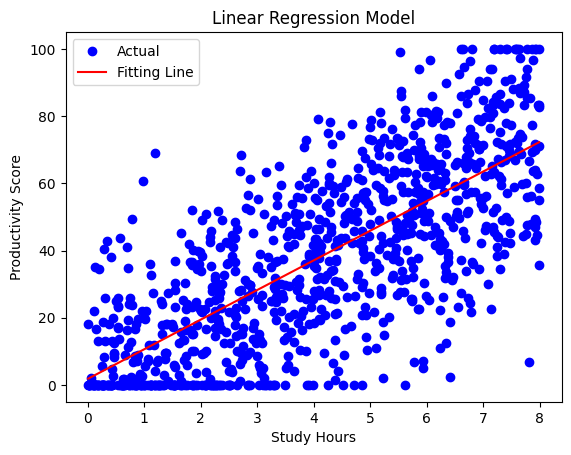

In [71]:
X_train_study_hours = X_train['study_hours']
X_test_study_hours = X_test['study_hours'] 

w, y_pred, mse, r2 = LinearRegressionScratch(X_train_study_hours, y_train, X_test_study_hours, y_test)

# Preparing the fitting line
w_0 = w[0]
w_1 = w[1]
x0 = np.min(X_test_study_hours)
x1 = np.max(X_test_study_hours)
y0 = w_0 + w_1 * x0
y1 = w_0 + w_1 * x1

# Model Visualization
plt.plot(X_test_study_hours, y_test, 'bo', label='Actual') # Plot actual values as blue points
plt.plot([x0, x1], [y0, y1], 'r-', label='Fitting Line') # Plot the fitting line
plt.xlabel('Study Hours') 
plt.ylabel('Productivity Score') 
plt.title('Linear Regression Model')
plt.legend() 
plt.show()



### Comparison with sklearn LinearRegression model

In [65]:
regr = linear_model.LinearRegression()
regr.fit(X_train_study_hours.values.reshape(-1, 1), y_train)
y_pred = regr.predict(X_test_study_hours.values.reshape(-1, 1))
y_test_np = y_test.values

print("Solution by LinearRegressionScratch:", r2)
print("Solution by scikit-learn LinearRegression:", r2_score(y_test_np, y_pred))
print("Difference in R-squared scores:", abs(r2 - r2_score(y_test_np, y_pred)))

Solution by LinearRegressionScratch: 0.5585788270610916
Solution by scikit-learn LinearRegression: 0.5585788270610916
Difference in R-squared scores: 0.0


### Multiple Linear Regression

Mean Squared Error: 89.6485358257079
R-squared score: 0.8793003017536232


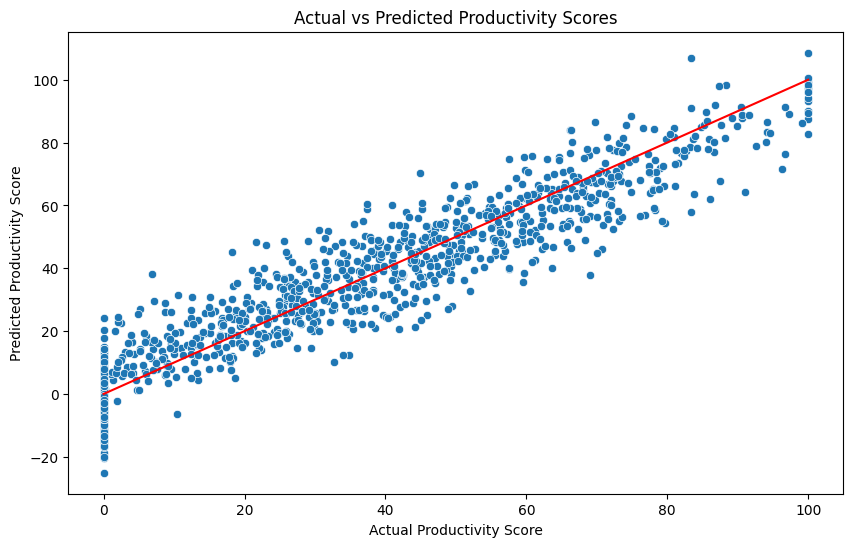

Solution by LinearRegressionScratch (MLR): 0.8793003017536232
Solution by scikit-learn LinearRegression (MLR): 0.8793003017536624
Difference in R-squared scores (MLR): 3.9190872769268026e-14


In [78]:
w_mlr, y_pred_mlr, mse_mlr, r2_mlr = LinearRegressionScratch(X_train, y_train, X_test, y_test)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_np, y=y_pred_mlr) # Create a scatter plot of actual vs predicted values
plt.plot([y_test_np.min(), y_test_np.max()], [y_test_np.min(), y_test_np.max()], 'r') # Add a reference line for perfect predictions
plt.xlabel('Actual Productivity Score')
plt.ylabel('Predicted Productivity Score')
plt.title('Actual vs Predicted Productivity Scores')
plt.show() 

# Comparison with scikit-learn's LinearRegression
regr_mlr = linear_model.LinearRegression()
regr_mlr.fit(X_train, y_train)
y_pred_mlr_sklearn = regr_mlr.predict(X_test)
print("Solution by LinearRegressionScratch (MLR):", r2_mlr)
print("Solution by scikit-learn LinearRegression (MLR):", r2_score(y_test_np, y_pred_mlr_sklearn))
print("Difference in R-squared scores (MLR):", abs(r2_mlr - r2_score(y_test_np, y_pred_mlr_sklearn)))
